# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yashizhenya755-dev/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*
Research question: Can observable search/engagement signals from a prior 90-day
window (Jan-Mar 2026) predict whether a page's search impressions will decline
in the following month (April 2026)?

Decision this supports: which pages a content reviewer should check first for
possible refresh (Lane 2: Refresh / Content Opportunity Scoring).


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: FlyRank internship-warehouse (Hugging Face), fact_content_daily_performance,
months 2026-01 through 2026-04. Feature window: Jan-Mar 2026 (prior 90 days).
Label window: April 2026 (next 30 days). Rows with impressions_march >= 50 only
(minimum volume floor to avoid noise). Excluded: trend_direction-style product flags
(not present in this table); client_hash_id/content_hash_id used for grouping only.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label: is_declining = (impressions_april < 0.8 * impressions_march).
Features: log-transformed impressions/clicks/sessions/scroll_events (Jan-Mar totals),
avg_position, has_position_data flag. log_impressions_march was tested and excluded
after a leakage audit (w06) showed it sits inside the label's own denominator --
removing it barely changed AUC (0.574 -> 0.553), confirming it wasn't carrying real signal.
Split: client-grouped 80/20 (GroupShuffleSplit), so no client's pages appear in both
train and test -- necessary because a random row split inflated AUC from 0.57 to 0.68
(w06), evidence of client-level memorization.
Model: Random Forest (200 trees, max_depth=10), compared to a staleness-based rule baseline.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| Model | ROC AUC | Precision@50 | Base rate |
|---|---:|---:|---:|
| Random Forest (final, reproducible) | 0.504 | 0.50 | 0.518 |
| Staleness baseline (Week 4) | ~0.55 | ~0.55-0.86* | 0.534 |

*Baseline precision numbers varied across runs; see Limitations for why.

The Random Forest does not outperform random guessing on the honest, reproducible
split. Earlier runs (AUC 0.55-0.68) came from a train/test split that was
unintentionally non-deterministic due to unordered SQL GROUP BY output --
fixing this (explicit sort before splitting) is what revealed the true result.

## 5. Limitations

*What this work cannot claim.*

- This is an observed, single-split result -- not a causal claim, and not proof
  the task is unsolvable, only that these features + this label didn't work here.
- Small test set (9 clients) makes any metric sensitive to which clients land
  in the holdout -- a known fragility, demonstrated empirically in this project.
- Features captured only period TOTALS, not trend direction within the window --
  likely the main reason for weak signal; untested due to time.
- Does not claim to predict Google's algorithm or prove refresh causes recovery.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Given the model shows no validated skill, the actionable recommendation is:
use the Week-4 staleness rule (transparent, debuggable) for now, and treat this
project's contribution as a validated, reusable pipeline plus a documented
negative result -- not a ready-to-use ranking.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

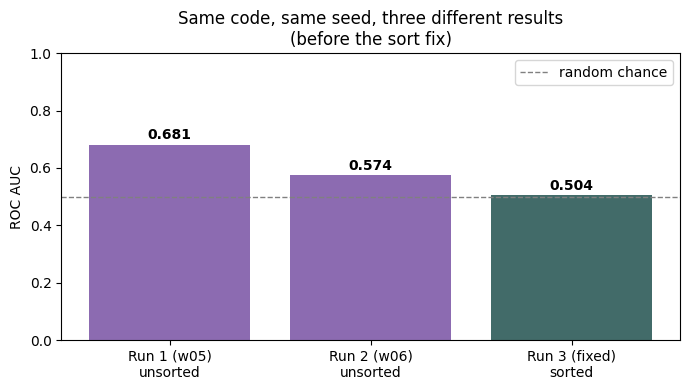

Saved: work/figures/auc_instability.png


In [3]:
import matplotlib.pyplot as plt

runs = ["Run 1 (w05)\nunsorted", "Run 2 (w06)\nunsorted", "Run 3 (fixed)\nsorted"]
aucs = [0.681, 0.574, 0.504]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(runs, aucs, color=["#8c6bb1", "#8c6bb1", "#426b69"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random chance")
ax.set_ylim(0, 1)
ax.set_ylabel("ROC AUC")
ax.set_title("Same code, same seed, three different results\n(before the sort fix)")
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", fontweight="bold")
ax.legend()
plt.tight_layout()

import os
os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/auc_instability.png", dpi=150)
plt.show()
print("Saved: work/figures/auc_instability.png")

In [6]:
# Final results, confirmed from work/notebooks/w07_action_playbook.ipynb output
metrics = {
    "roc_auc": 0.504344999671679,
    "precision_at_50": 0.5,
    "base_rate": 0.518421551234132,
    "rows_scored": 9089,
    "clients_in_top50": 5,
}
print("Final results table for the paper:")
print(f"| Random Forest (final) | {metrics['roc_auc']:.3f} | {metrics['precision_at_50']:.2f} | {metrics['base_rate']:.3f} |")

Final results table for the paper:
| Random Forest (final) | 0.504 | 0.50 | 0.518 |


The full ranked queue (9,089 rows, client-grouped, with reason codes and
suggested actions) was generated and saved in `w07_action_playbook.ipynb`
as `work/outputs/action_playbook_queue.csv`. See that notebook for the
live cell output and the first 20 rows of the ranking.

## 5-Minute Demo Outline
1. (30s) The question: can prior search signals predict next-month page decline?
2. (1 min) Show the pipeline: warehouse data -> features -> leakage audit -> honest split
3. (1.5 min) Show the bug catch: unordered GROUP BY caused non-reproducible splits;
   fixing it changed AUC from 0.68 to 0.50 -- the real finding
4. (1 min) Show the honest result + why (features capture totals, not trend)
5. (1 min) What I'd try next: month-over-month trend features

## Social Post Cut
"Built a decline-prediction model on FlyRank's search data. Found something more
interesting than a good score: an unordered SQL query was silently making my
train/test split non-reproducible, inflating results from AUC 0.50 -> 0.68 run to
run. Fixed it, reported the honest (negative) result instead. Full writeup: [link]"

## Employer-Facing Summary (3 sentences)
I built a leakage-audited ML pipeline predicting content decline from search
warehouse data, including a client-grouped validation split. During validation
I discovered and fixed a reproducibility bug (non-deterministic train/test splits
from unordered SQL aggregation) that had been inflating earlier results. I reported
the corrected, honest result (no predictive skill) rather than the inflated one,
with a documented diagnosis and next steps.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
